## Consensus NMF (cNMF)


In [1]:
# switch into project root directory for working links in interactive mode
import os
import re
os.chdir(re.sub('results/.*$|workflow/.*$', '', os.getcwd()))

#----- Import all libraries
import sys as sys
import re
import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import scanpy as sc
from cnmf import cNMF
import shutil
import argparse

In [2]:
input_file = 'results/merged/chosen_branch/Conti/adata.h5ad'
count_layer = 'counts'
deviant_genes_file = 'results/merged/chosen_branch/Conti/deviant_genes.txt'

In [3]:
#----- Set parameters
run_name = 'cNMF'
seedx = 14 ## Specify a seed pseudorandom number generation for reproducibility
numiter=200 # Number of NMF replicates. Set this to a larger value ~200 for real data. We set this to a relatively low value here for illustration at a faster speed
numhvgenes=2000 ## Number of over-dispersed genes to use for running the actual factorizations
comp=np.arange(2,19) # Range of number of components to try
num_workers = 32  # Number of workers
output_directory = re.sub('adata.*.h5ad', 'cNMF_' + count_layer, input_file)

In [4]:
## Initialize the cnmf object that will be used to run analyses
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)
## Get results
cnmf_obj.combine()

Combining factorizations for k=2.
Combining factorizations for k=3.
Combining factorizations for k=4.
Combining factorizations for k=5.
Combining factorizations for k=6.
Combining factorizations for k=7.
Combining factorizations for k=8.
Combining factorizations for k=9.
Combining factorizations for k=10.
Combining factorizations for k=11.
Combining factorizations for k=12.
Combining factorizations for k=13.
Combining factorizations for k=14.
Combining factorizations for k=15.
Combining factorizations for k=16.
Combining factorizations for k=17.
Combining factorizations for k=18.


In [ ]:
# cnmf_obj.k_selection_plot(close_fig=False)
# print('This saves the corresponding figure to the following file: %s' % cnmf_obj.paths['k_selection_plot'])

In [5]:
# select k automatically

import cnmf as cnmf

run_params = cnmf.load_df_from_npz(cnmf_obj.paths['nmf_replicate_parameters'])
stats = []
norm_counts = sc.read(cnmf_obj.paths['normalized_counts'])
for k in sorted(set(run_params.n_components)):
	stats.append(cnmf_obj.consensus(k, skip_density_and_return_after_stats=True,
								show_clustering=False, close_clustergram_fig=True,
								norm_counts=norm_counts).stats)

stats = pd.DataFrame(stats)
stats.reset_index(drop = True, inplace = True)

# select k with highest stability / error ratio
# s = stats['stability/error'] = stats['silhouette'] / stats['prediction_error']
# best_k = stats.loc[s.idxmax(), 'k'].astype(int)

# select best k with stability above 95%
# k_above_95 = 

# best_k

In [6]:
stats

,k,local_density_threshold,silhouette,prediction_error
0,2.0,0.5,0.999981,6.095084e+07
1,3.0,0.5,0.997556,5.883651e+07
2,4.0,0.5,0.996989,5.751187e+07
3,5.0,0.5,0.836770,5.640807e+07
4,6.0,0.5,0.942174,5.552106e+07
5,7.0,0.5,0.982428,5.470408e+07
6,8.0,0.5,0.991836,5.406323e+07
7,9.0,0.5,0.984879,5.352786e+07
8,10.0,0.5,0.785360,5.313610e+07
9,11.0,0.5,0.813198,5.268621e+07


In [7]:
s = stats['stability/error'] = stats['silhouette'] / stats['prediction_error']
best_k = stats.loc[s.idxmax(), 'k'].astype(int)
best_k

9

In [8]:
high = stats[stats['silhouette'] > 0.95]
# k with lowest prediction error
best_k = high.loc[high['prediction_error'].idxmin(), 'k'].astype(int)
best_k

9

/data/cephfs-1/home/users/cemo10_c/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


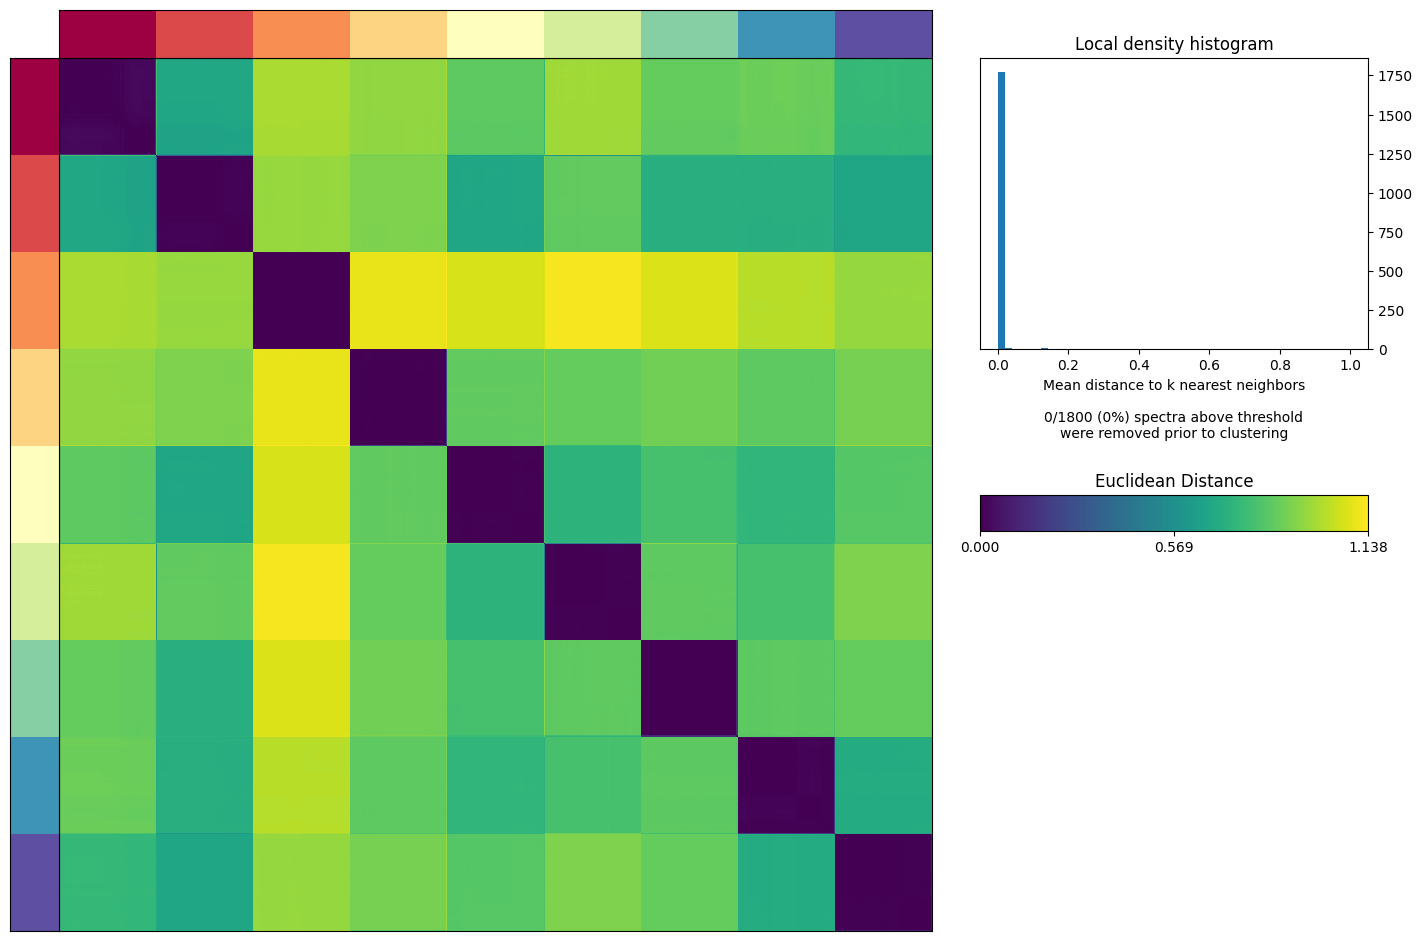

In [9]:
density_threshold = 2.00
cnmf_obj.consensus(k=best_k, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

### Associated pathways

::: {.panel-tabset}

#### Gene ontology: Biological pathways

/data/cephfs-1/home/users/cemo10_c/scratch/tmp/hpc-cpu-22/ipykernel_3580093/3996848765.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


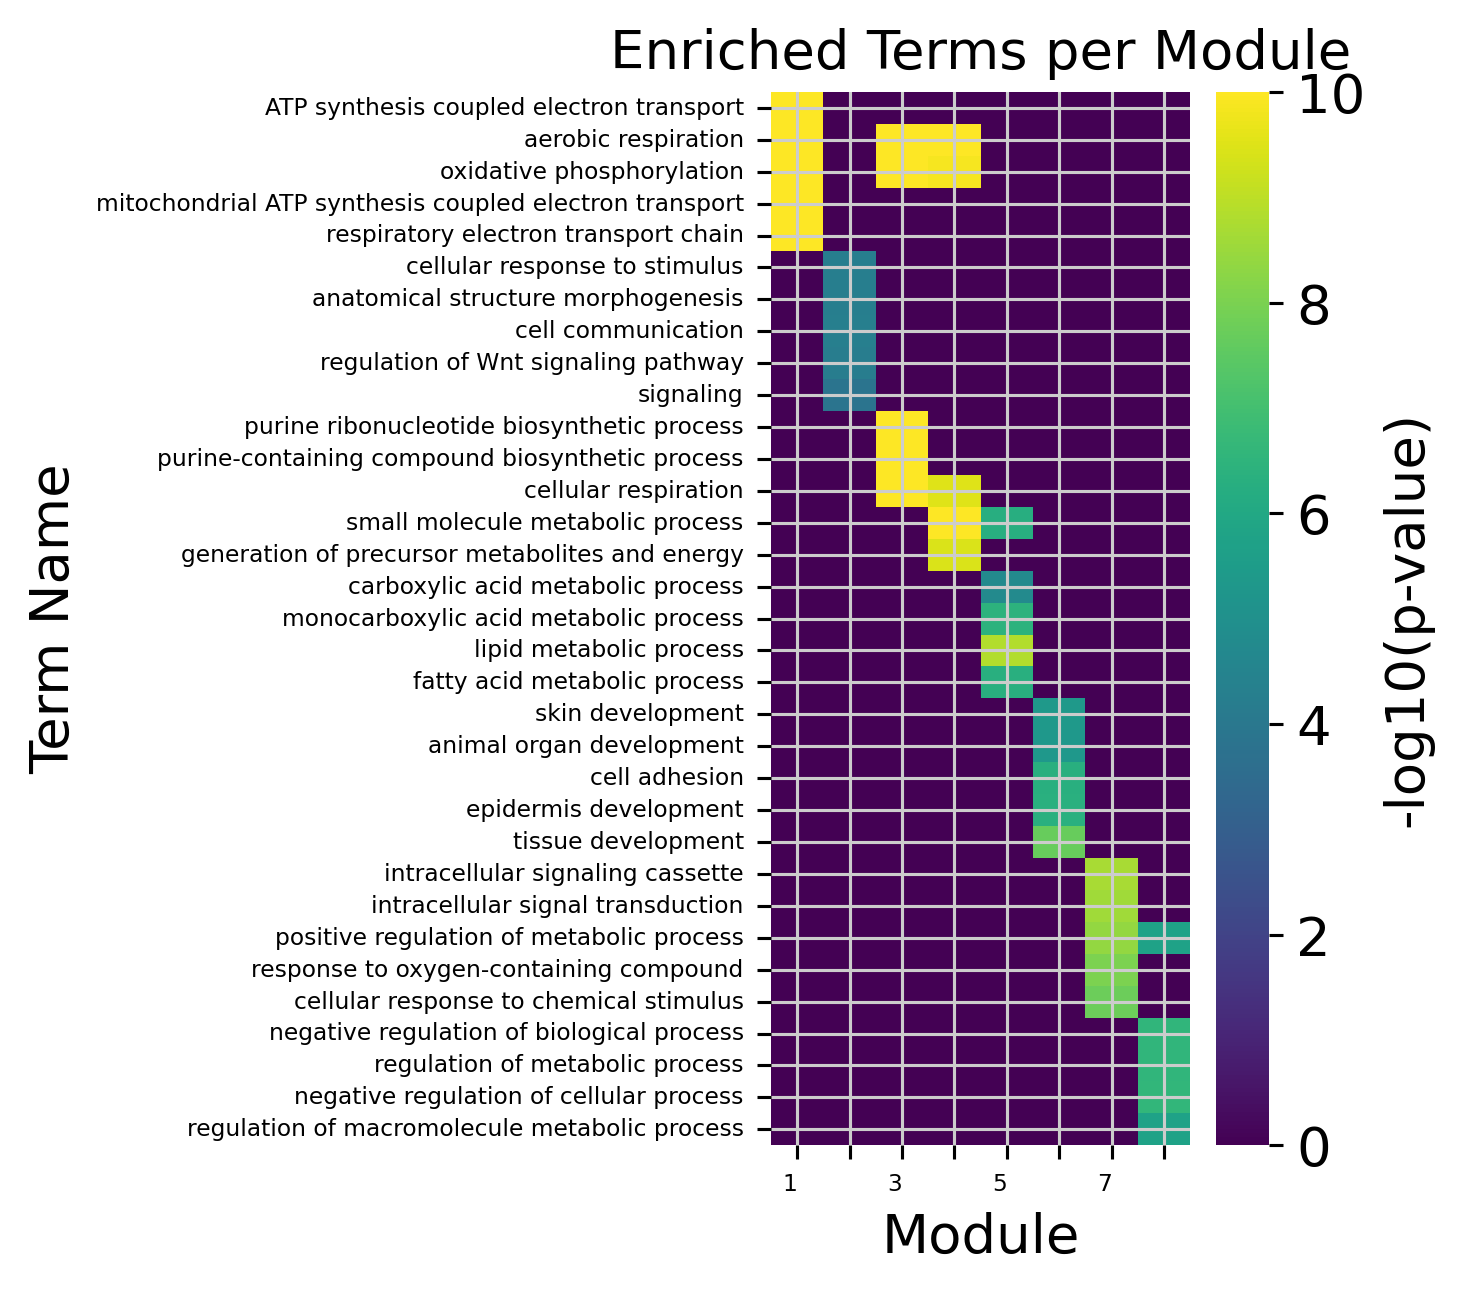

In [14]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=best_k, density_threshold=density_threshold)

# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens", gprofiler_kwargs = {'sources':['GO:BP']})
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(5).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1], 0.15 * dotplot_data.shape[0]))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

/data/cephfs-1/home/users/cemo10_c/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


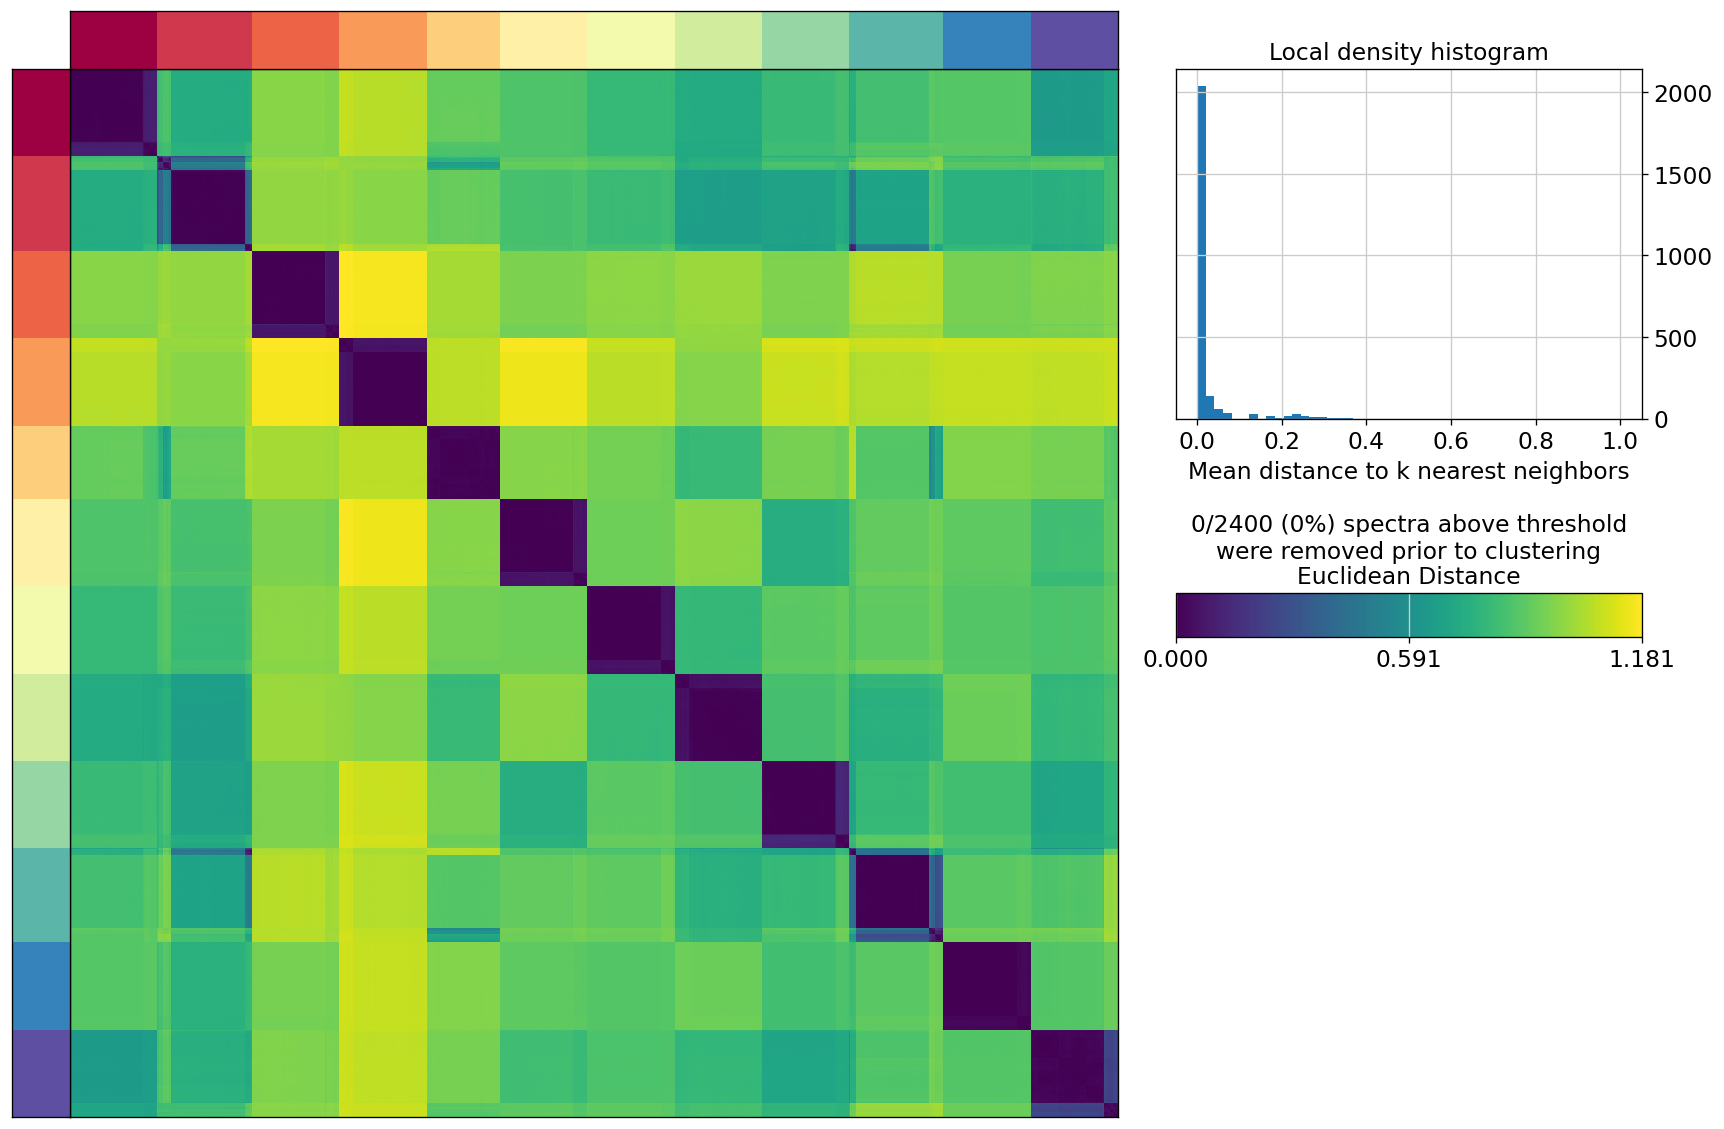

In [16]:
density_threshold = 2.00
cnmf_obj.consensus(k=12, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

/data/cephfs-1/home/users/cemo10_c/scratch/tmp/hpc-cpu-22/ipykernel_3580093/910066633.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


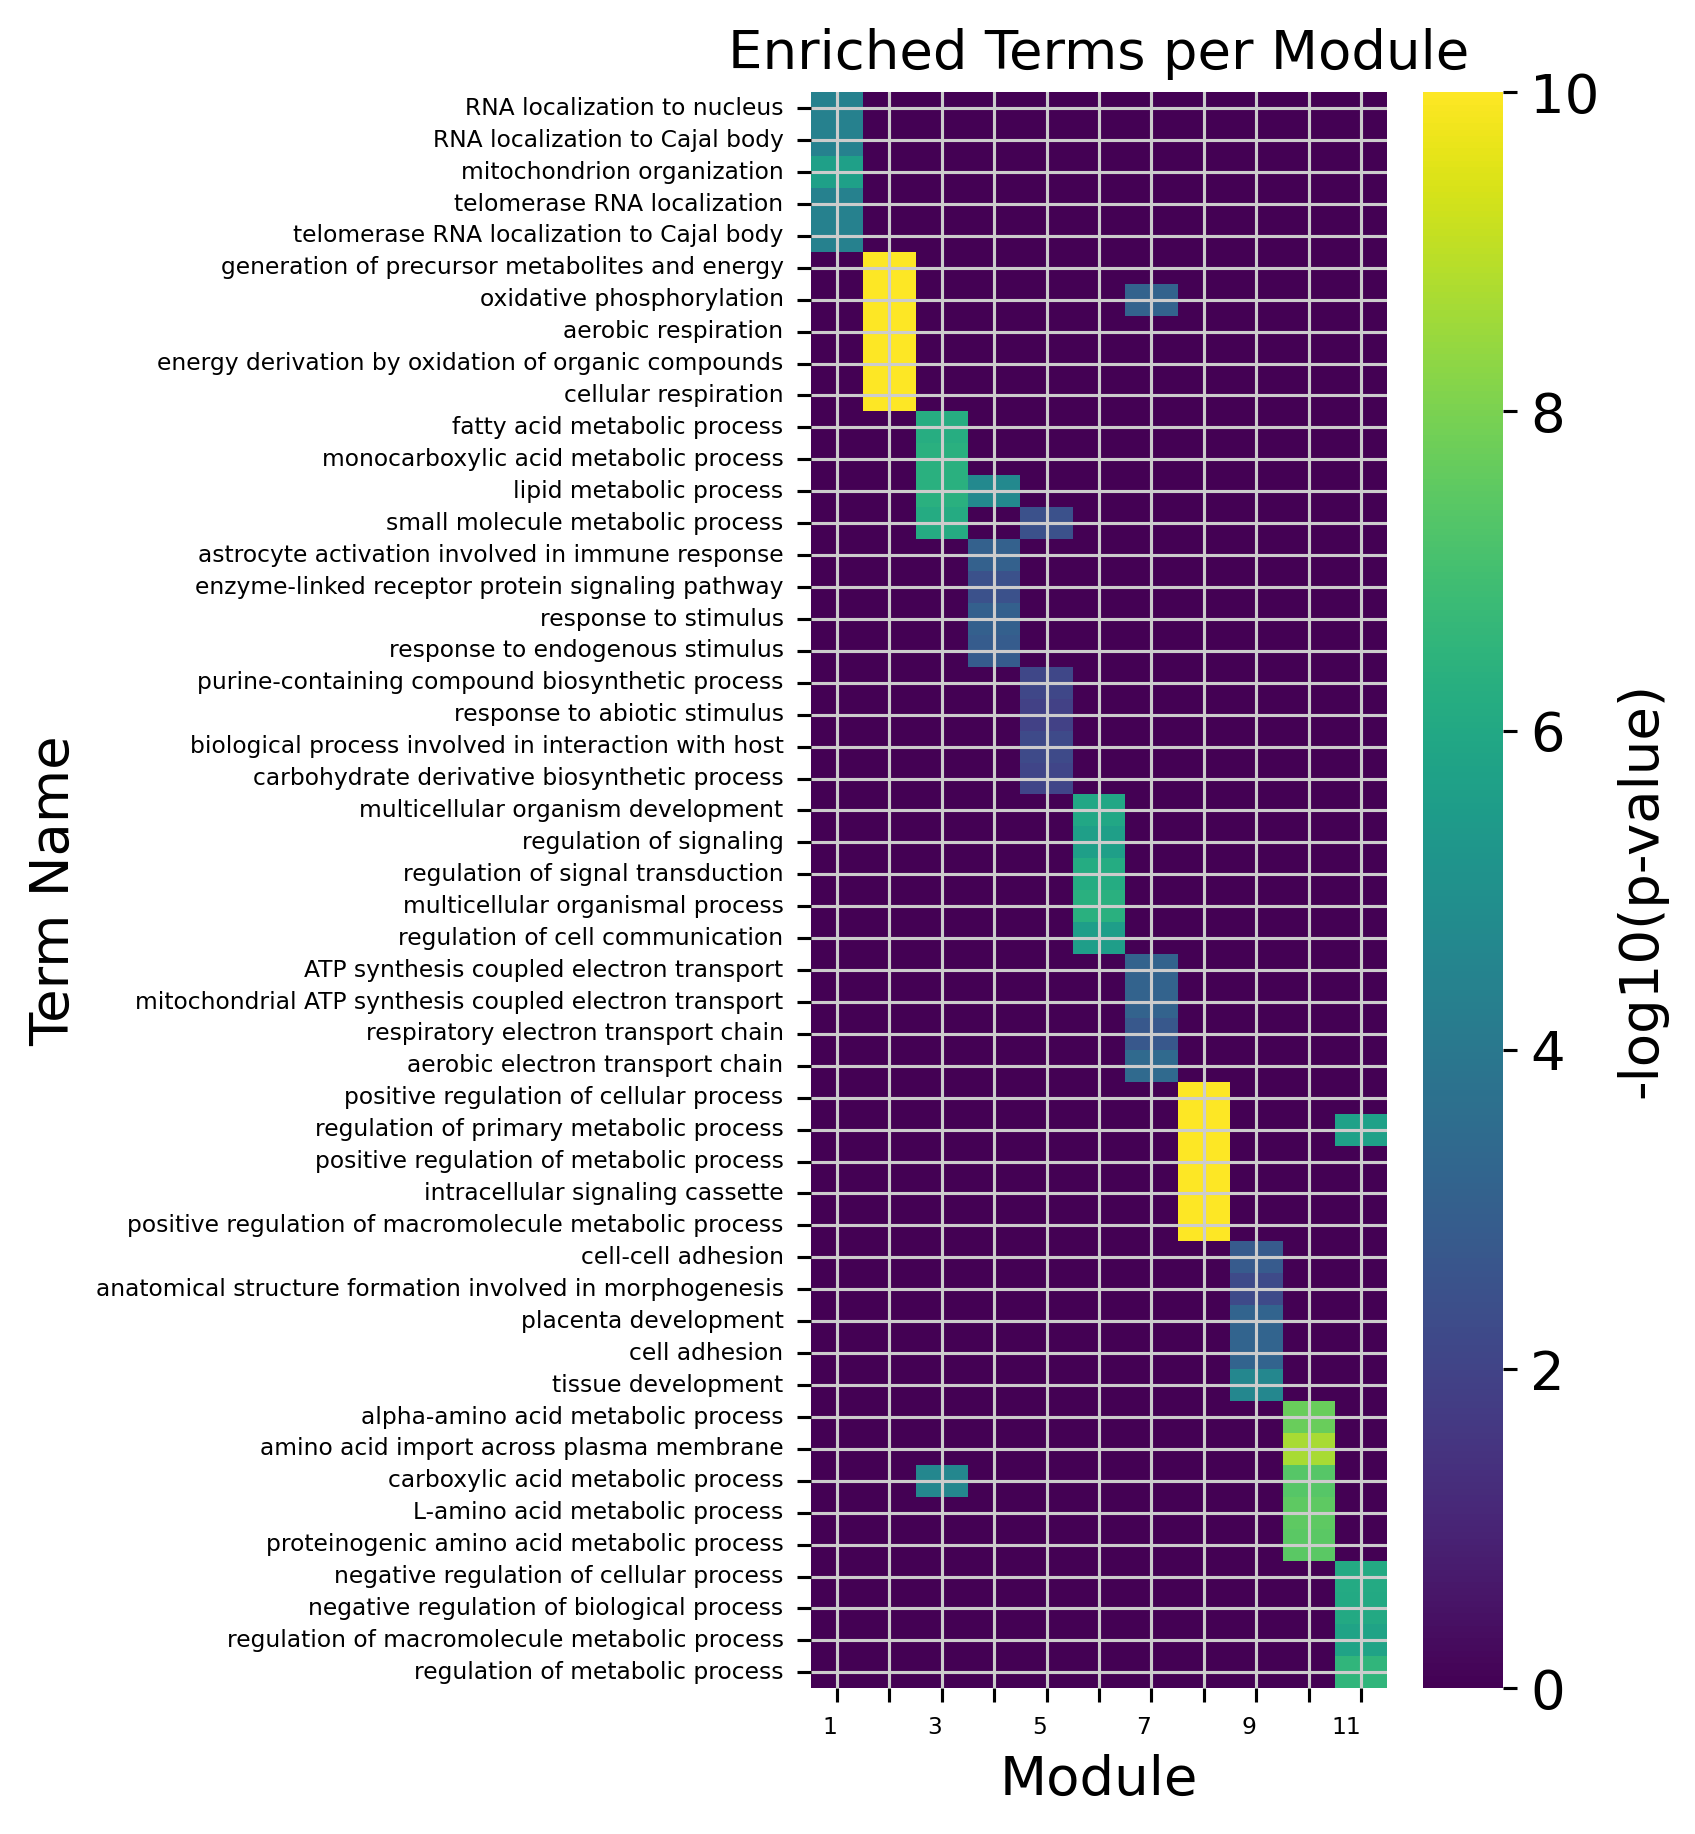

In [18]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=12, density_threshold=density_threshold)

# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens", gprofiler_kwargs = {'sources':['GO:BP']})
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(5).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1], 0.15 * dotplot_data.shape[0]))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

/data/cephfs-1/home/users/cemo10_c/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


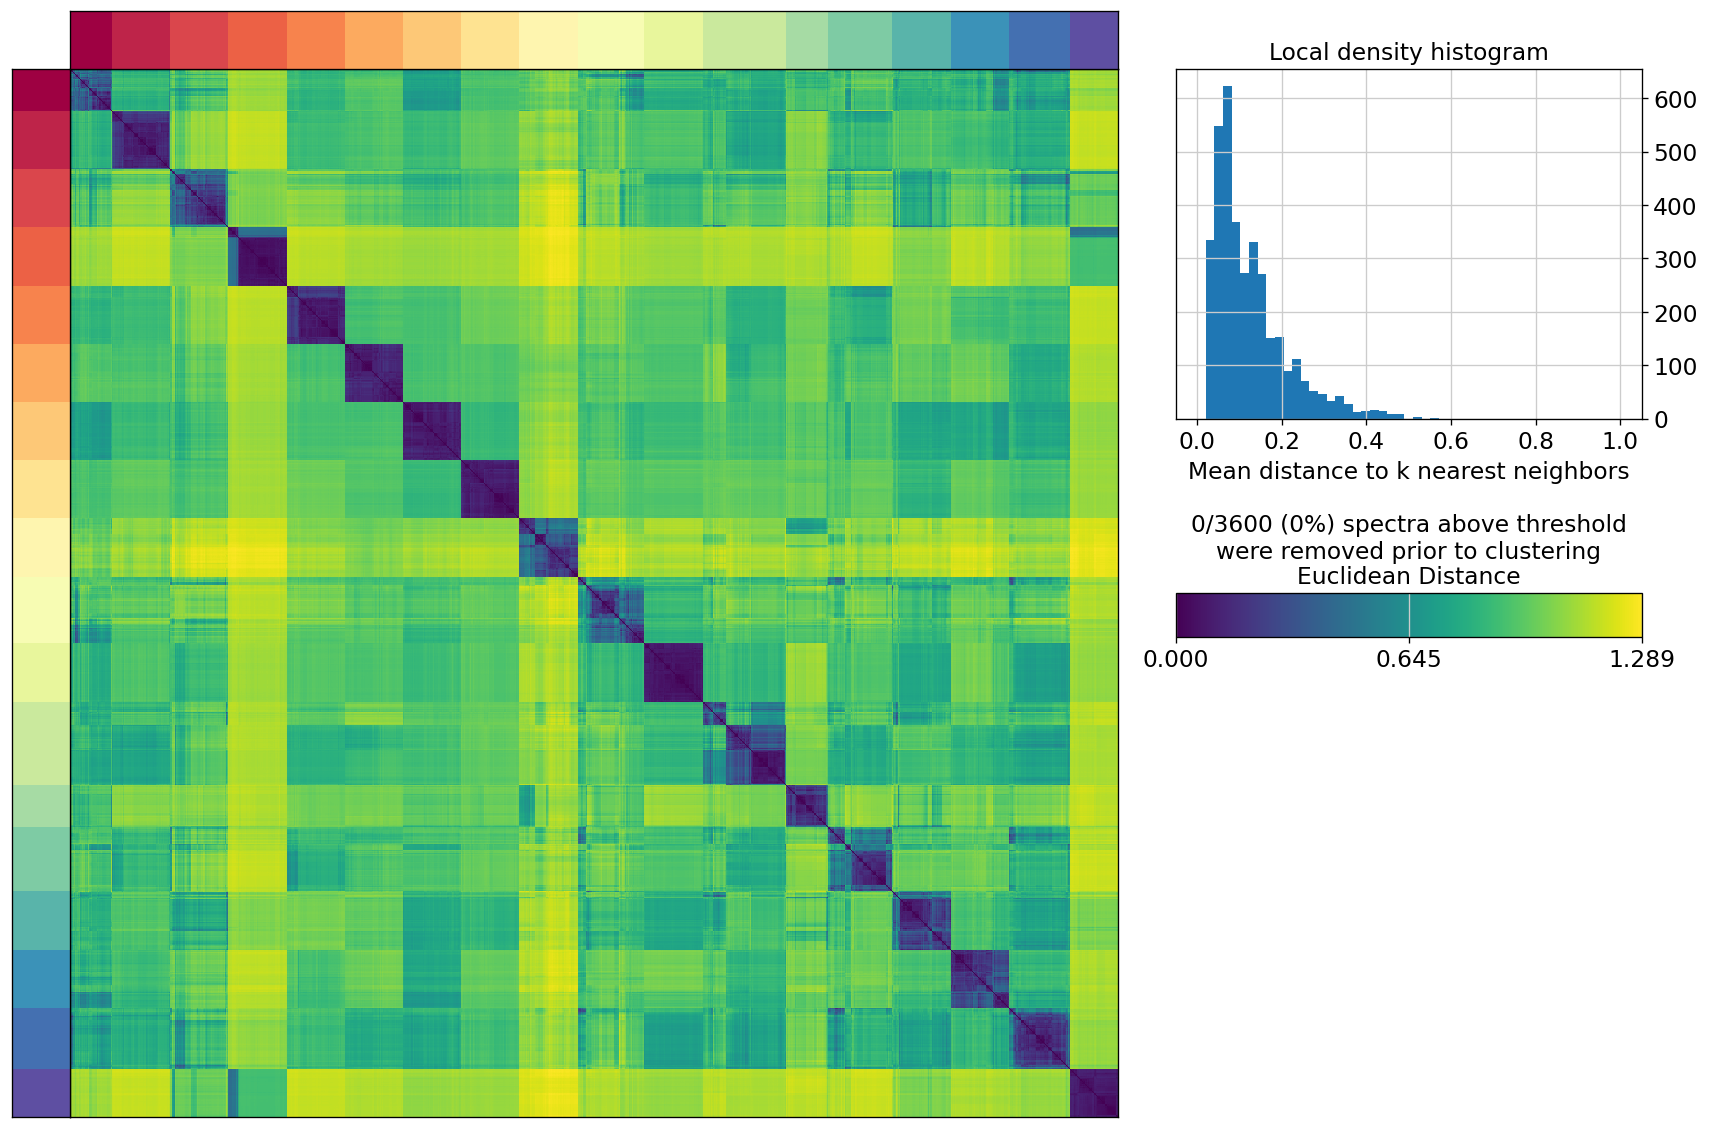

In [19]:
density_threshold = 2.00
cnmf_obj.consensus(k=18, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

/data/cephfs-1/home/users/cemo10_c/scratch/tmp/hpc-cpu-22/ipykernel_3580093/3074777320.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  top_terms = pd.concat(top_terms)


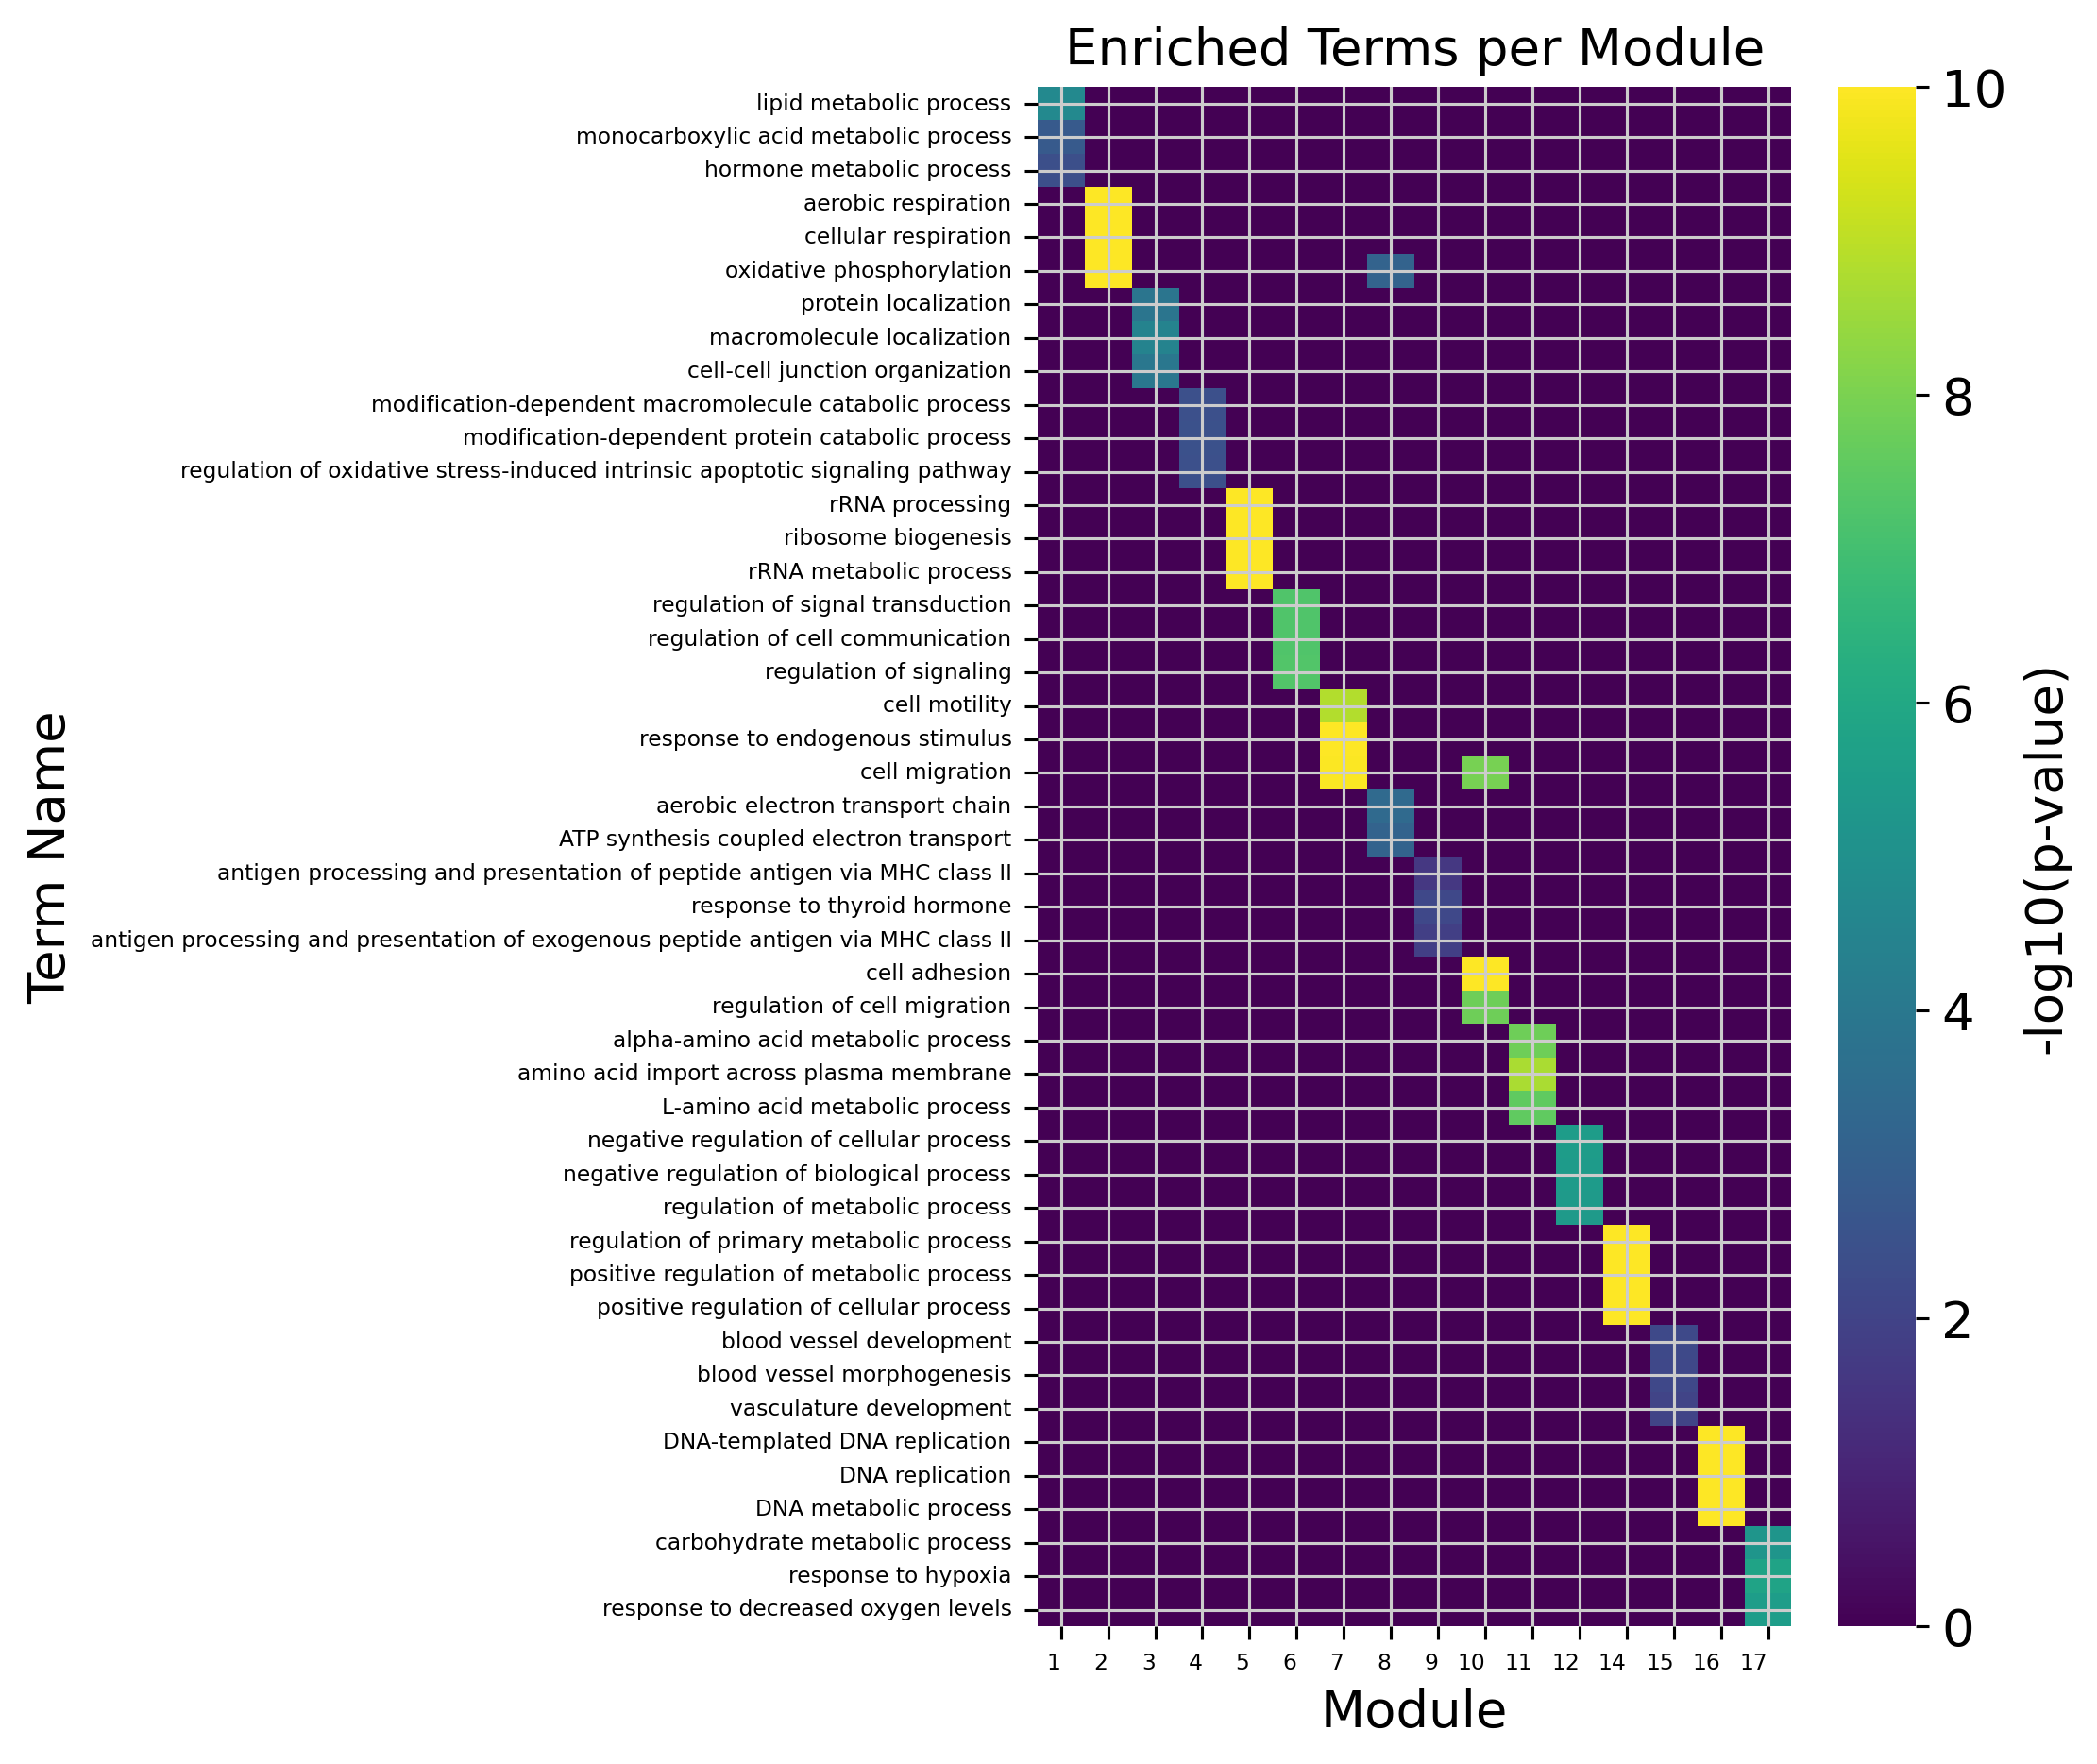

In [23]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=18, density_threshold=density_threshold)

# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens", gprofiler_kwargs = {'sources':['GO:BP']})
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(3).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1] + 3, 0.15 * dotplot_data.shape[0]))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

#### Gene ontology: Molecular pathways

/data/cephfs-1/home/users/cemo10_c/scratch/tmp/hpc-cpu-25/ipykernel_1894171/4056596019.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


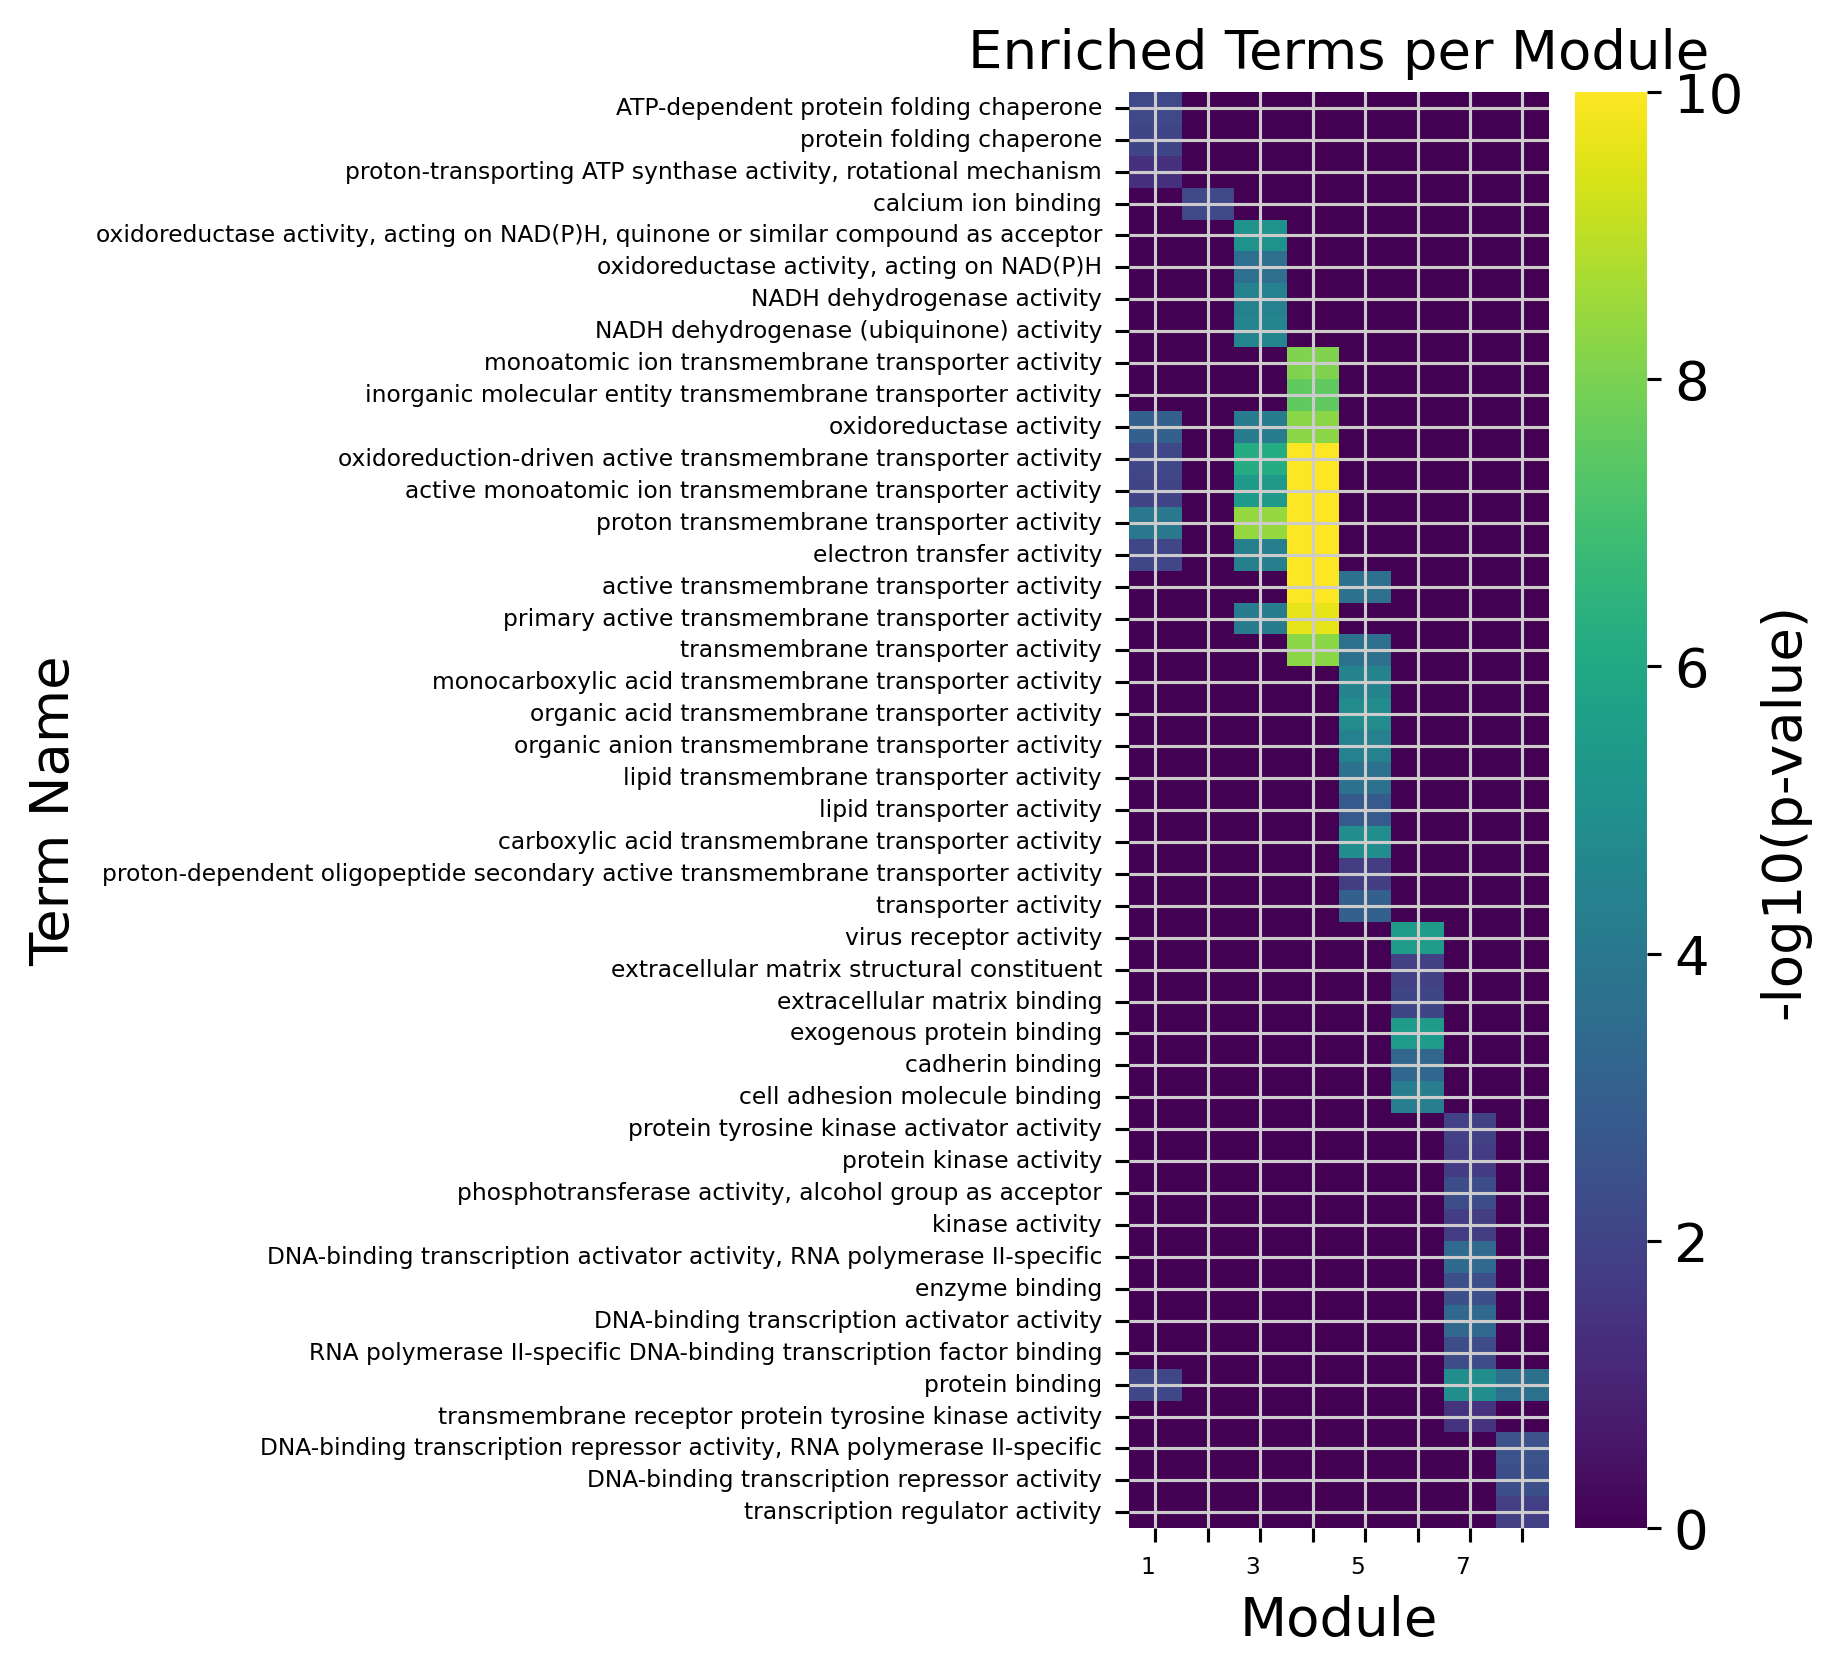

In [ ]:
# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens", gprofiler_kwargs = {'sources':['GO:MF']})
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(10).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1], 0.15 * dotplot_data.shape[0]))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

#### Reactome

In [ ]:
# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens", gprofiler_kwargs = {'sources':['REAC']})
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(10).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1], 0.15 * dotplot_data.shape[0]))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
#### All pathways in gprofiler

In [ ]:
# enrichment for every module and then dotplot
enrichments = {}
for i in range(1, topgenes.shape[1]):
	genes = topgenes[i].tolist()
	enrich = sc.queries.enrich(genes, org="hsapiens")
	enrichments[i] = enrich

enrichments

# Add a column with module number to top_terms
top_terms = []
for i in enrichments:
	top = enrichments[i].head(10).copy()
	top['module'] = i
	top_terms.append(top)
top_terms = pd.concat(top_terms)

# pivot the table
dotplot_data = top_terms.pivot(index='name', columns='module', values='p_value')
# add a column which indicates the module with the lowest p-value
dotplot_data['module'] = dotplot_data.idxmin(axis=1)
# sort by module
dotplot_data = dotplot_data.sort_values(by='module')
# remove the column module from index
dotplot_data = dotplot_data.drop(columns=['module'])
# replace NaN with 1
dotplot_data = dotplot_data.fillna(1)
# -log10 transform
dotplot_data = -np.log10(dotplot_data)
# set -log10(20) to maximum
dotplot_data[dotplot_data > 10] = 10

# dotplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# make a dotplot for the top enriched terms per module
sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False, transparent=True)
plt.figure(figsize=(0.3 * dotplot_data.shape[1], 0.15 * dotplot_data.shape[0]))
# plt.figure(figsize=(12, 8))
ax = sns.heatmap(dotplot_data, annot=False, cmap='viridis')
ax.set_yticks(np.arange(dotplot_data.shape[0]) + 0.5)  # +0.5 centers the labels
ax.set_yticklabels(dotplot_data.index, rotation=0, fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right', fontsize=6)
ax.set_xticks(np.arange(dotplot_data.shape[1]) + 0.5)  # +0.5 centers the labels
plt.gca().collections[0].colorbar.set_label('-log10(p-value)')
plt.title('Enriched Terms per Module')
plt.xlabel('Module')
plt.ylabel('Term Name')
plt.tight_layout()
plt.show()

sc.settings.set_figure_params(dpi=60, facecolor="white", frameon=False, transparent=True)

:::

### Module weights per sample

In [ ]:
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how='left', left_index=True, right_index=True)

sc.pl.umap(adata, color=usage_norm.columns,
           use_raw=False, ncols=3, vmin=0, vmax=1)

In [ ]:
# add column with samples from adata.obs to usage_norm
if 'sample' in adata.obs_keys():
    assert all(adata.obs['sample'].index == usage_norm.index) # check
    usage_norm['sample'] = adata.obs['sample'].values

::: {.panel-tabset}

#### Violin plots

In [ ]:
# Get top pathway name for each module
top_pathways = top_terms.groupby('module')['name'].first().to_dict()

usage_cols = [col for col in usage_norm.columns if col.startswith("Usage_")]
for usage_col in usage_cols:
	module_num = int(usage_col.split("_")[1])
	pathway = top_pathways.get(module_num, "")
	plt.figure(figsize=(12, 6))
	sns.violinplot(data=usage_norm, x='sample', y=usage_col, palette="Set3", inner="box")
	plt.ylim(bottom=0)
	plt.title(f"Module {module_num}: {pathway}")
	plt.xlabel("Sample")
	plt.ylabel(f"Usage Value for {usage_col}")
	sample_sizes = usage_norm['sample'].value_counts()
	zero_counts = usage_norm.groupby('sample')[usage_col].apply(lambda x: (x == 0).sum())
	zero_percent = (zero_counts / sample_sizes * 100).round(0).astype(int)
	for i, sample in enumerate(zero_percent.index):
		plt.text(i, plt.ylim()[1]*0.95, f"zeros: {zero_percent[sample]}%", ha='center', va='top', fontsize=8, color='black')
	plt.show()

#### Dotplot

In [ ]:
import numpy as np
from matplotlib.legend import Legend

# same as dotplot with modules in columns and samples in rows, point size is percentage expressed and color is median expression excluding zeros
import matplotlib.pyplot as plt

# Prepare data for dotplot
samples = usage_norm['sample'].unique()
modules = usage_cols

# Calculate percentage expressed and median expression (excluding zeros) for each sample and module
percent_expressed = np.zeros((len(samples), len(modules)))
median_expr = np.zeros((len(samples), len(modules)))

for i, sample in enumerate(samples):
	sample_mask = usage_norm['sample'] == sample
	for j, module in enumerate(modules):
		vals = usage_norm.loc[sample_mask, module]
		nonzero = vals[vals > 0]
		percent_expressed[i, j] = (vals > 0).mean() * 100
		median_expr[i, j] = np.median(nonzero) if len(nonzero) > 0 else 0

# Plot dotplot with bigger points
plt.figure(figsize=(0.7 * len(modules), 0.4 * len(samples)))
scatter = plt.scatter(
	np.tile(np.arange(len(modules)), len(samples)),
	np.repeat(np.arange(len(samples)), len(modules)),
	s=percent_expressed.flatten() * 2,  # increase point size
	c=median_expr.flatten(),
	cmap='viridis',
	vmin=0,
	vmax=np.percentile(median_expr, 99)
)
plt.xticks(np.arange(len(modules)), [col.replace('Usage_', '') for col in modules], rotation=90)
plt.yticks(np.arange(len(samples)), samples)
plt.xlabel('Module')
plt.ylabel('Sample')
plt.title('Module Usage: % Expressed (size), Median (color)')
plt.colorbar(scatter, label='Median Usage (excluding zeros)')
# Add point size legend outside of plot area

handles = [plt.scatter([], [], s=size * 2, c='gray') for size in [20, 50, 80]]
labels = [f'{size}% expressed' for size in [20, 50, 80]]
plt.legend(handles, labels, scatterpoints=1, frameon=False, labelspacing=1, title='Point size', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

:::